## **LOAD THE DATA**

In [2]:
import os
from datasets import load_dataset
from pathlib import Path
import pandas as pd

In [3]:
script = Path.cwd()
root = script.parent
df = pd.read_csv(root/"data"/"raw_data"/'data.csv')

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df.head()

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,...,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,...,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,...,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,...,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,...,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1


In [5]:
print("Rows    : ",df.shape[0])
print("Columns : ",df.shape[1])

Rows    :  36992
Columns :  24


In [6]:
df.describe()

,Unnamed: 0,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,18495.500000,37.118161,-41.915576,243.472334,29271.194003,686.882199,0.540982
std,10678.814916,15.867412,228.819900,398.289149,19444.806226,194.063624,0.498324
min,0.000000,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,9247.750000,23.000000,8.000000,60.102500,14177.540000,616.150000,0.000000
50%,18495.500000,37.000000,12.000000,161.765000,27554.485000,697.620000,1.000000
75%,27743.250000,51.000000,16.000000,356.515000,40855.110000,763.950000,1.000000
max,36991.000000,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


In [7]:
df.loc[df['referral_id']=="xxxxxxxx"] = np.nan

In [8]:
df['referral_id'].isna().sum()

np.int64(17846)

In [9]:
df['referral_id'].isna().sum()/len(df)

np.float64(0.48242863321799306)

### **48% of the referral ids are missing**

In [10]:
df['referral_id'].fillna('no referral')

0        no referral
1           CID21329
2           CID12313
3            CID3793
4        no referral
            ...     
36987    no referral
36988    no referral
36989        CID3838
36990    no referral
36991    no referral
Name: referral_id, Length: 36992, dtype: str

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    19146 non-null  float64
 1   age                           19146 non-null  float64
 2   gender                        19146 non-null  str    
 3   security_no                   19146 non-null  str    
 4   region_category               16288 non-null  str    
 5   membership_category           19146 non-null  str    
 6   joining_date                  19146 non-null  str    
 7   joined_through_referral       19146 non-null  str    
 8   referral_id                   19146 non-null  str    
 9   preferred_offer_types         18982 non-null  str    
 10  medium_of_operation           19146 non-null  str    
 11  internet_option               19146 non-null  str    
 12  last_visit_time               19146 non-null  str    
 13  days_since_l

In [12]:
df.dtypes

Unnamed: 0                      float64
age                             float64
gender                              str
security_no                         str
region_category                     str
membership_category                 str
joining_date                        str
joined_through_referral             str
referral_id                         str
preferred_offer_types               str
medium_of_operation                 str
internet_option                     str
last_visit_time                     str
days_since_last_login           float64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days            str
points_in_wallet                float64
used_special_discount               str
offer_application_preference        str
past_complaint                      str
complaint_status                    str
feedback                            str
churn_risk_score                float64
dtype: object

In [13]:
df['joined_through_referral'].value_counts()

joined_through_referral
Yes    14269
?       4877
Name: count, dtype: int64

In [14]:
df['joined_through_referral'].nunique()

2

In [15]:
df.loc[df['days_since_last_login']==-999] = np.nan

In [16]:
df.describe()

,Unnamed: 0,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,18053.000000,18053.000000,18053.000000,18053.000000,18053.000000,16359.000000,18053.000000
mean,18520.899241,37.165734,12.596244,287.726649,28772.609837,685.297626,0.557082
std,10718.364558,15.830902,5.572966,432.844464,18755.823458,194.191789,0.496745
min,1.000000,10.000000,1.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,9205.000000,24.000000,9.000000,61.290000,14131.530000,615.540000,0.000000
50%,18641.000000,37.000000,13.000000,165.420000,27446.080000,693.960000,1.000000
75%,27758.000000,51.000000,17.000000,494.120000,40428.420000,761.840000,1.000000
max,36989.000000,64.000000,26.000000,3235.578521,99861.470000,1759.002532,1.000000


#### **Fill missing values in preferred_offer_types with 'Missing' word**

In [17]:
df['preferred_offer_types'] = df['preferred_offer_types'].fillna('Missing')

In [18]:
df.groupby('preferred_offer_types')['churn_risk_score'].mean()

preferred_offer_types
Credit/Debit Card Offers    0.543874
Gift Vouchers/Coupons       0.540997
Missing                     0.605096
Without Offers              0.585312
Name: churn_risk_score, dtype: float64

##### So we can infer that the missing ones are just random missing data not a part to concern about

In [19]:
df['preferred_offer_types'].value_counts()

preferred_offer_types
Missing                     19096
Credit/Debit Card Offers     5983
Gift Vouchers/Coupons        5976
Without Offers               5937
Name: count, dtype: int64

In [20]:
df.isna().sum()

Unnamed: 0                      18939
age                             18939
gender                          18939
security_no                     18939
region_category                 21629
membership_category             18939
joining_date                    18939
joined_through_referral         18939
referral_id                     18939
preferred_offer_types               0
medium_of_operation             18939
internet_option                 18939
last_visit_time                 18939
days_since_last_login           18939
avg_time_spent                  18939
avg_transaction_value           18939
avg_frequency_login_days        18939
points_in_wallet                20633
used_special_discount           18939
offer_application_preference    18939
past_complaint                  18939
complaint_status                18939
feedback                        18939
churn_risk_score                18939
dtype: int64

In [21]:
(df['points_in_wallet'].isna().sum()/len(df))*100

np.float64(55.776924740484425)

In [22]:
mean_value = df['points_in_wallet'].mean()
mean_value

np.float64(685.2976261419484)

In [23]:
df['points_in_wallet'] = df['points_in_wallet'].fillna(mean_value)

In [24]:
df.isna().sum()

Unnamed: 0                      18939
age                             18939
gender                          18939
security_no                     18939
region_category                 21629
membership_category             18939
joining_date                    18939
joined_through_referral         18939
referral_id                     18939
preferred_offer_types               0
medium_of_operation             18939
internet_option                 18939
last_visit_time                 18939
days_since_last_login           18939
avg_time_spent                  18939
avg_transaction_value           18939
avg_frequency_login_days        18939
points_in_wallet                    0
used_special_discount           18939
offer_application_preference    18939
past_complaint                  18939
complaint_status                18939
feedback                        18939
churn_risk_score                18939
dtype: int64

#### Churn per category

In [25]:
category_churn = df.groupby('membership_category')['churn_risk_score'].mean().reset_index()
category_churn

,membership_category,churn_risk_score
0,Basic Membership,0.967222
1,Gold Membership,0.391065
2,No Membership,0.971509
3,Platinum Membership,0.000000
4,Premium Membership,0.000000
5,Silver Membership,0.431810


Text(0, 0.5, 'Membership Category')

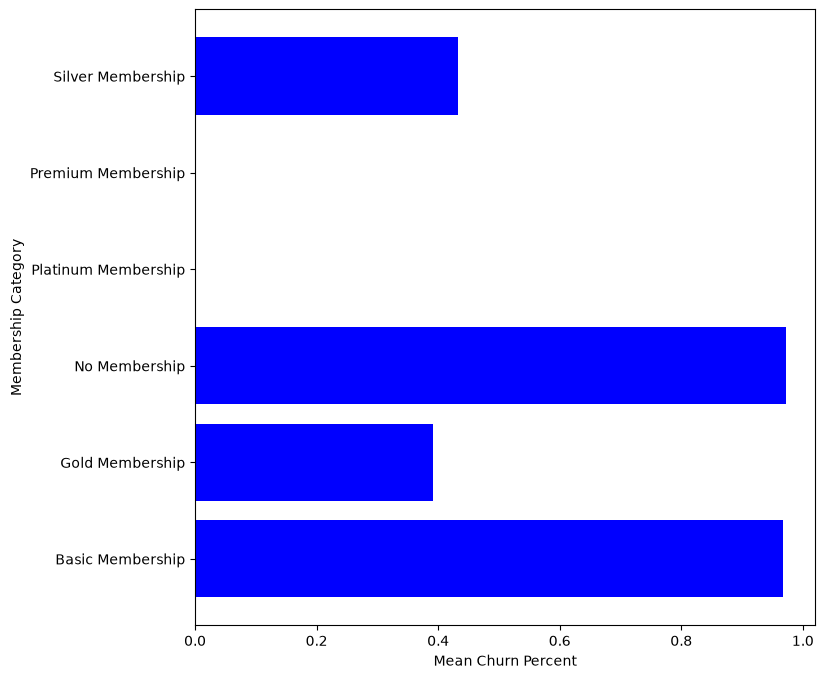

In [26]:
plt.figure(figsize=(8, 8))
plt.barh(category_churn['membership_category'],category_churn['churn_risk_score'],color = 'blue')
plt.xlabel('Mean Churn Percent')
plt.ylabel('Membership Category')

In [27]:
df['internet_option'].value_counts()

internet_option
Fiber_Optic    6032
Wi-Fi          6030
Mobile_Data    5991
Name: count, dtype: int64

### Churn per Internet Option

In [28]:
internet_churn = df.groupby('internet_option')['churn_risk_score'].mean().reset_index()
internet_churn

,internet_option,churn_risk_score
0,Fiber_Optic,0.563660
1,Mobile_Data,0.561676
2,Wi-Fi,0.545937


Text(0, 0.5, 'Churn Rate')

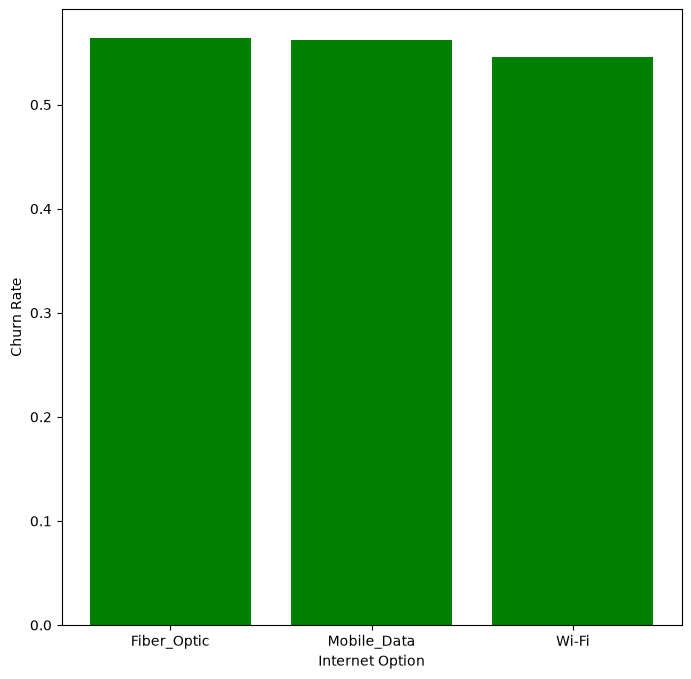

In [29]:
plt.figure(figsize=(8, 8))
plt.bar(internet_churn['internet_option'],internet_churn['churn_risk_score'],color = 'green')
plt.xlabel('Internet Option')
plt.ylabel('Churn Rate')

## Univariate Distributions

In [30]:
numerical_columns = ["age","churn_risk_score","points_in_wallet",
"avg_transaction_value","avg_time_spent","days_since_last_login"]

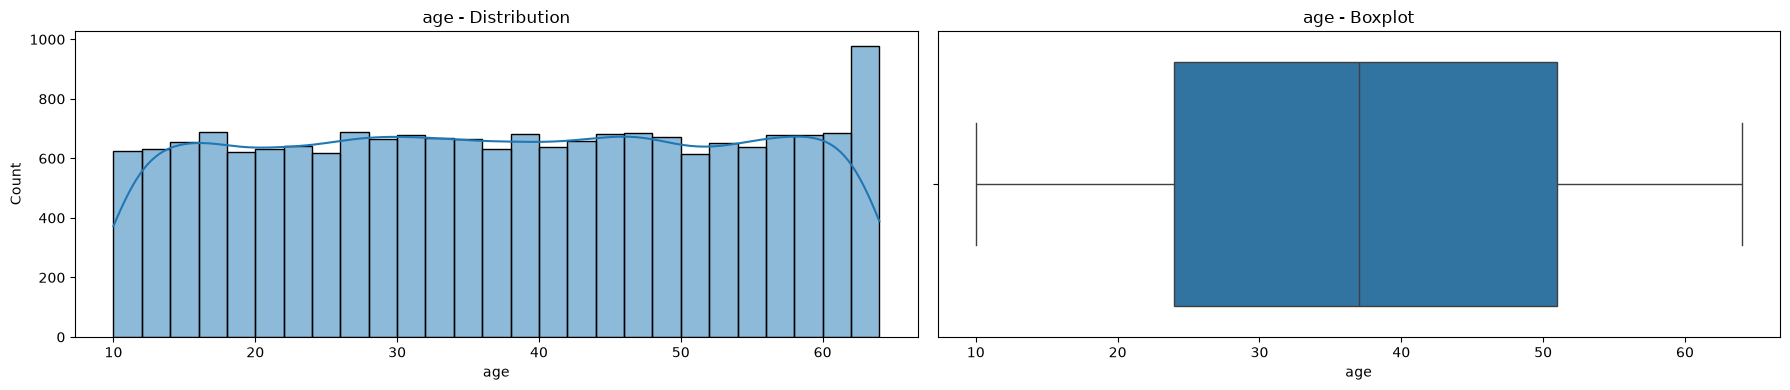

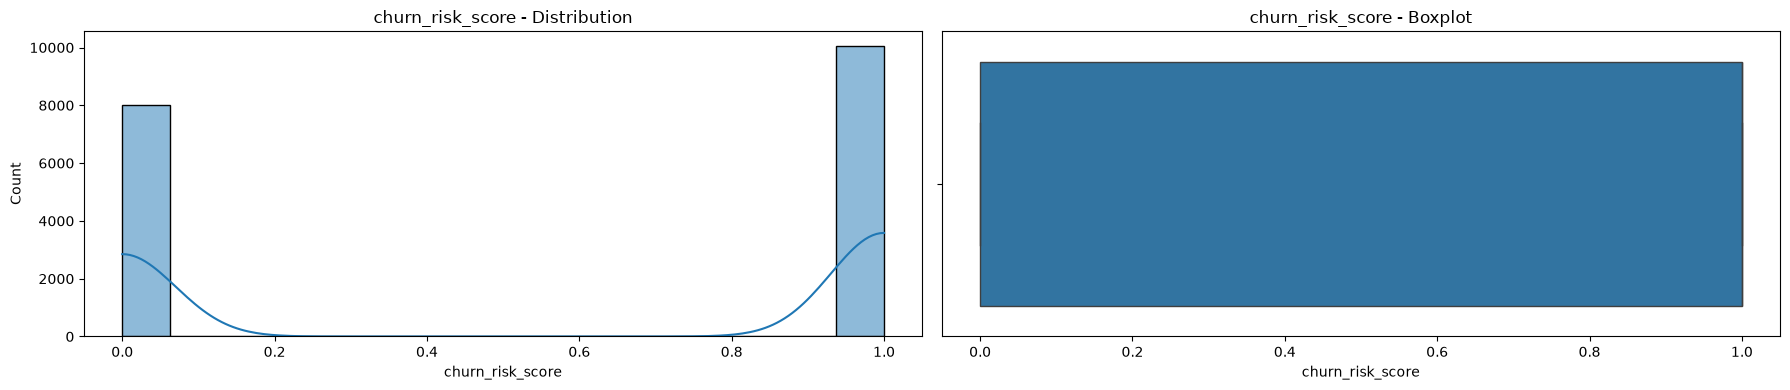

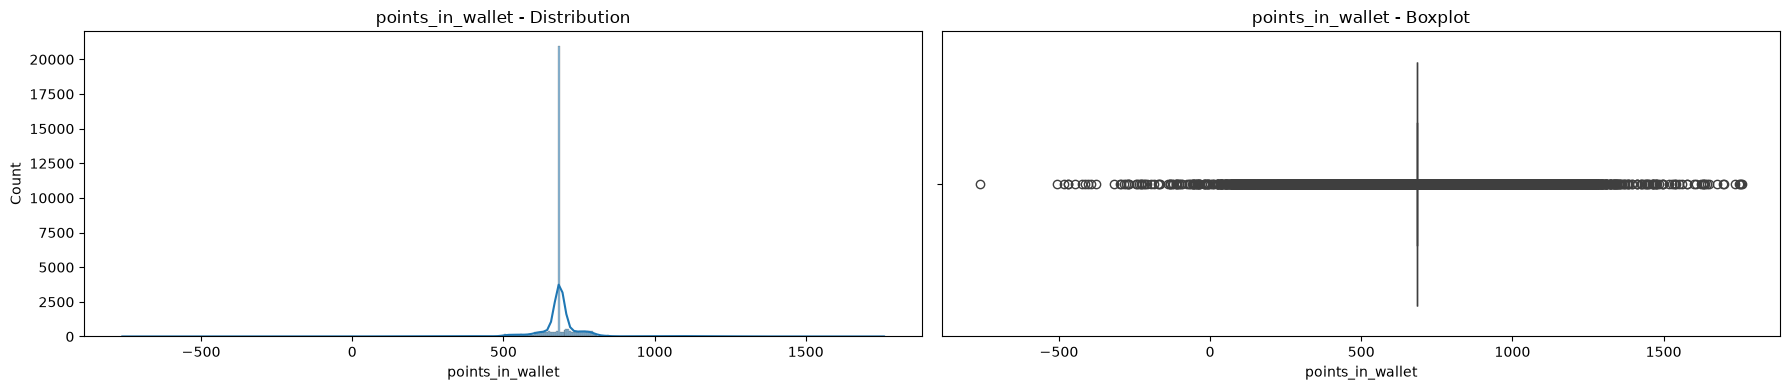

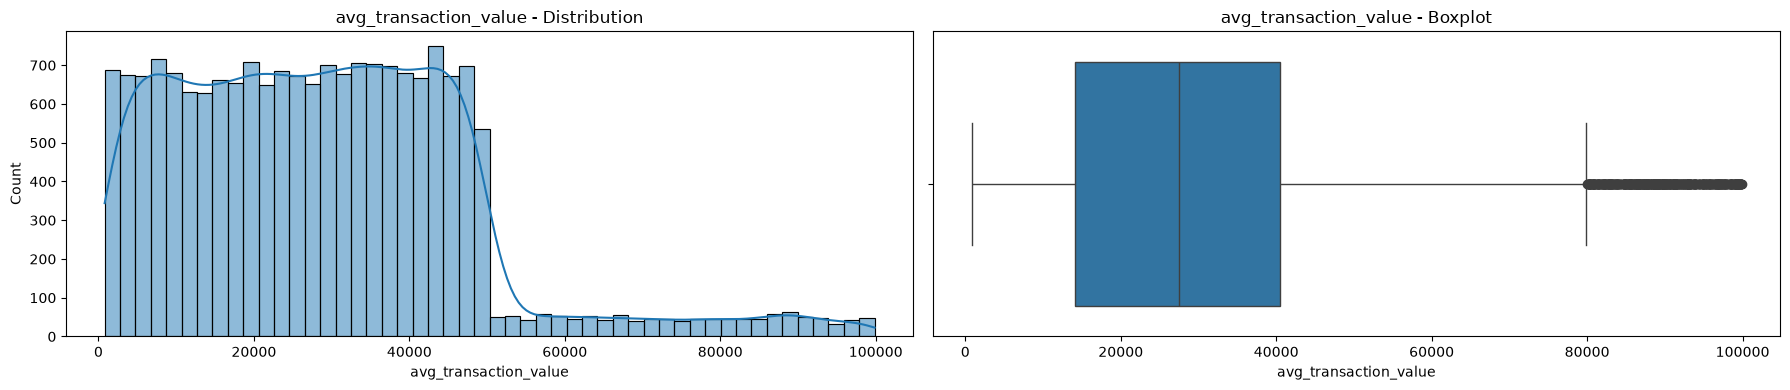

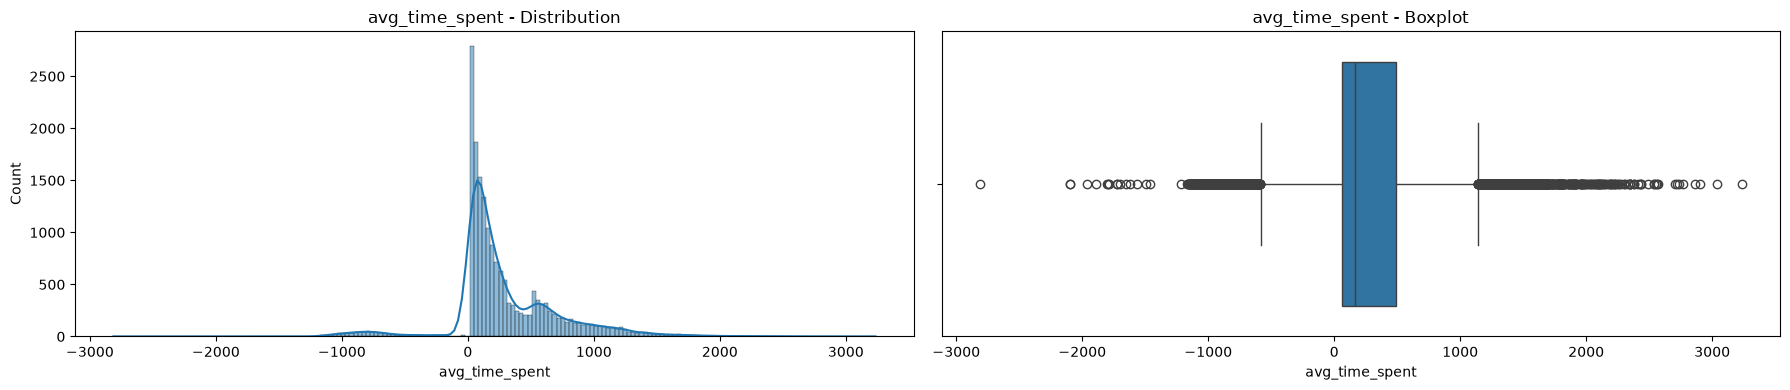

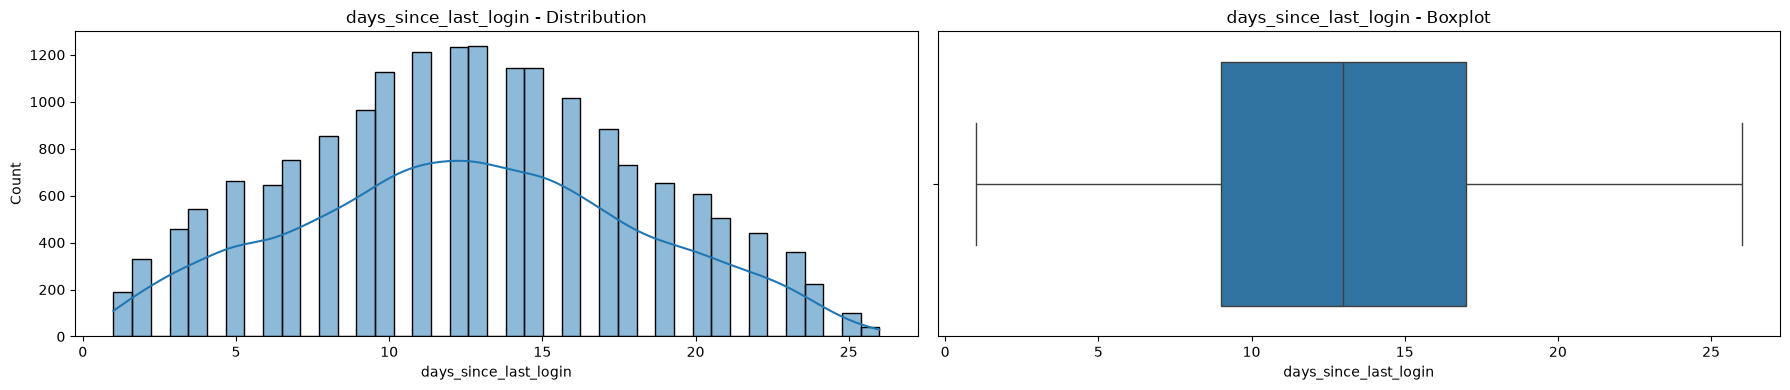

In [31]:
for col in numerical_columns:
    fig,axes = plt.subplots(1,2,figsize=(18,4))
    sns.histplot(df[col],kde=True,ax=axes[0])
    axes[0].set_title(f'{col} - Distribution')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')
    plt.tight_layout()
    plt.show()